# How to train a neural network to flag spam

## Abstract

This is an AI pipeline that demonstrates the use of advanced AI tools used to classify messages as 'spam' or 'not spam'. We will be using the Kaggle dataset ([sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)) to train the model to classify different test messages. Python packages such as pandas, PyTorch, and numpy will be used to pre-process and train a model. We will use MatPlotLib to visualise the results as well as visual correlations between data. We will cleanse and tokenise our data so that it can be processed by our neural network.

## Set up

### Required dependencies

You can find all required dependencies in the [requriements.txt](./requirements.txt)

### Virtual enviroment

This is because you want to isolate dependencies into its own enviroment so you don't install unneccessary dependencies outside of the virtual env.

For MacOSX

```bash
python3 -m venv venv
source venv/bin/activate
pip3 install -r ./requirements.txt
```

For Windows PowerShell

```powershell
python -m venv venv
venv\Scripts\Activate.ps1
pip install -r requirements.txt
```

For Windows cmd

```cmd
python -m venv venv
venv\Scripts\activate.bat
pip install -r requirements.txt
```

## Importing dataset

In [18]:
import pandas as pd

# Latin1 encoding 
df = pd.read_csv("./spam.csv", encoding='latin1')

# Remove any empty rows
df = df.dropna(how="any", axis=1)
df.columns = ["label","message"]
# Binary values for ham (0) and spam (1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Label distribution

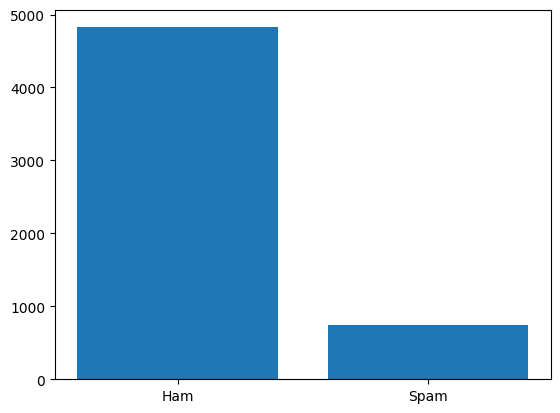

In [19]:
import matplotlib.pyplot as plt
import numpy as np

label_distribution = df.groupby("label")["label"].agg("count").values
label_distribution

x = np.array(["Ham","Spam"])
y = np.array(label_distribution)

plt.bar(x,y)
plt.show()

## Find correlation between length of message and label

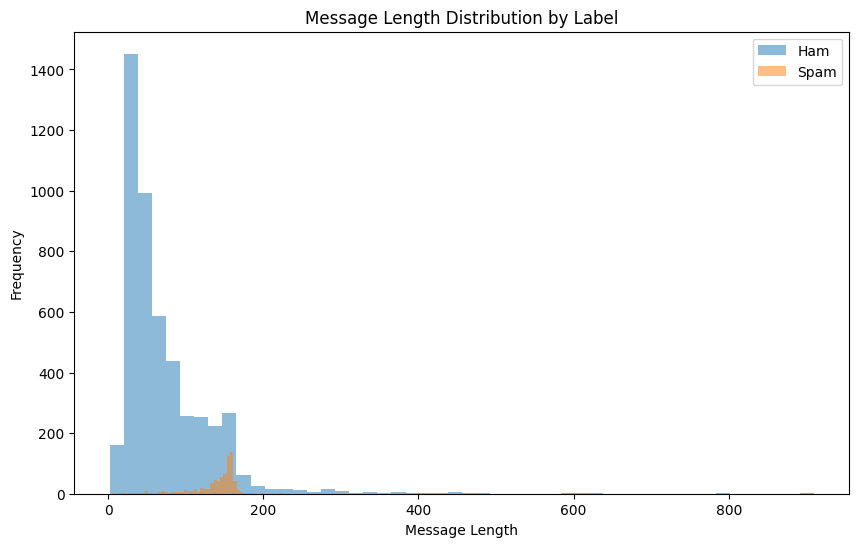

In [20]:
df['messageLen'] = df['message'].astype(str).map(len)
df.head()

df.groupby("label")["messageLen"].describe()

plt.figure(figsize=(10,6))

# Ham
plt.hist(df[df["label"] == 0]["messageLen"], 
         bins=50, alpha=0.5, label="Ham")

# Spam
plt.hist(df[df["label"] == 1]["messageLen"], 
         bins=50, alpha=0.5, label="Spam")

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution by Label")
plt.legend()
plt.show()

### Normalized as the dataset is imbalanced

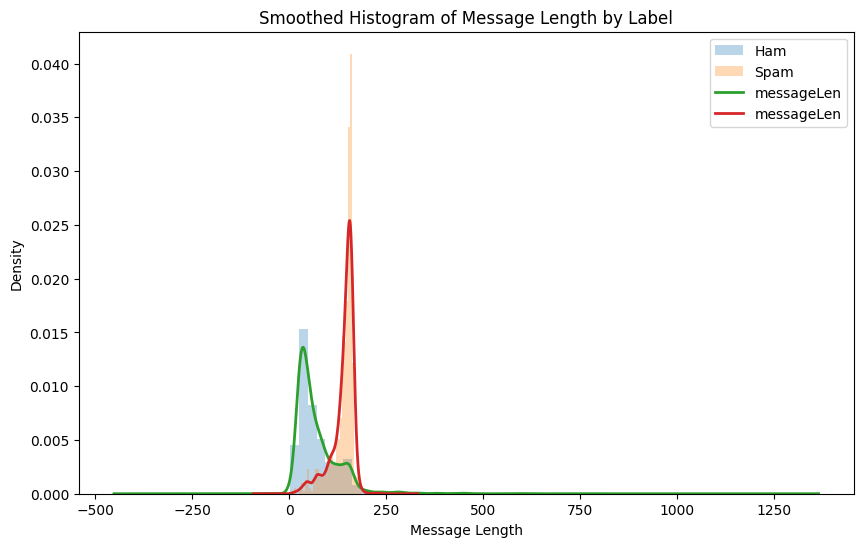

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ham = df[df["label"] == 0]["messageLen"]
spam = df[df["label"] == 1]["messageLen"]

# Histograms
plt.hist(ham, bins=40, density=True, alpha=0.3, label="Ham")
plt.hist(spam, bins=40, density=True, alpha=0.3, label="Spam")

# KDE lines
ham.plot(kind="kde", linewidth=2)
spam.plot(kind="kde", linewidth=2)

plt.xlabel("Message Length")
plt.ylabel("Density")
plt.title("Smoothed Histogram of Message Length by Label")
plt.legend()
plt.show()

### Dataset

The dataset comes from [Kaggle.com](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)

It is a collection of SMS messages which are classified as 'spam' or 'ham' (not spam)

The dataset is found in the [spam.csv](./spam.csv)